# Ярус C: GPT-2 124M (FineWeb-Edu) и GLUE (RoBERTa-base)

Масштабирование эффектов на языковые модели: предобучение, рестарты с чекпойнтов,
послойная диагностика, дообучение на GLUE. Все ячейки читают сохранённые результаты.

Перезапуск: `python -m theory_bench.gpt_bench --mode w --lr 3e-4 --wd 0.01 --tokens 1.5e9 --tag main`.

In [1]:
import json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RES = "../theory_bench/results"
FIGS = "../theory_bench/figs"
pd.set_option("display.precision", 4)

def show(name, width=900):
    display(Image(filename=os.path.join(FIGS, name), width=width))
GPT = f"{RES}/gpt"
GLUE = f"{RES}/glue"

## Пилотная сетка (100M токенов): развязка AdamW, $\lambda$-чувствительность AdamL2, расходимость AdamWH

In [2]:
rows = []
for f in sorted(glob.glob(f"{GPT}/pilot_*.json")):
    d = json.load(open(f))
    rows.append(dict(mode=d["mode"], lr=d["lr"], wd=d["wd"], final_val=d["final_val"]))
pd.DataFrame(rows).sort_values(["mode", "lr", "wd"])

,mode,lr,wd,final_val
0,l2,0.0003,0.010,6.8572
1,l2,0.0003,0.100,7.8141
2,l2,0.0006,0.010,7.0088
3,l2,0.0006,0.100,8.0609
4,w,0.0003,0.010,5.8346
5,w,0.0003,0.100,5.8348
6,w,0.0006,0.010,5.8574
7,w,0.0006,0.100,5.8524
8,wh,0.0003,0.001,NaN
9,wh,0.0003,0.010,NaN


## Основные запуски (1.5B токенов, 2 сида на метод)

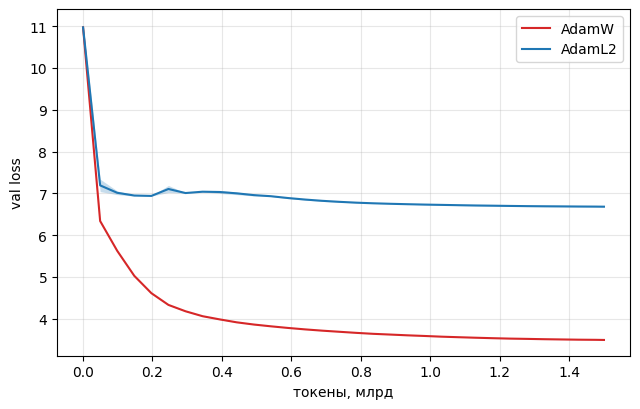

w final val: [3.4923, 3.4918]
l2 final val: [6.6707, 6.6897]


In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for mode, color, name in (("w", "tab:red", "AdamW"), ("l2", "tab:blue", "AdamL2")):
    cs = []
    for sd in (0, 1):
        d = json.load(open(f"{GPT}/main_{mode}_lr0.0003_wd0.01_s{sd}.json"))
        cs.append((np.array(d["val_at_tokens"]) / 1e9, np.array(d["val_loss"])))
    n = min(len(c[0]) for c in cs); x = cs[0][0][:n]
    ys = np.array([c[1][:n] for c in cs])
    ax.fill_between(x, ys.min(0), ys.max(0), color=color, alpha=0.25, lw=0)
    ax.plot(x, ys.mean(0), color=color, label=name)
ax.set_xlabel("токены, млрд"); ax.set_ylabel("val loss"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
for mode in ("w", "l2"):
    vals = [json.load(open(f"{GPT}/main_{mode}_lr0.0003_wd0.01_s{s}.json"))["final_val"] for s in (0, 1)]
    print(mode, "final val:", [round(v, 4) for v in vals])

## Послойная диагностика: авто-«no-decay»

Отношение $\|\nabla F\|^2/\|\nabla\widetilde F_t\|^2$ в конце обучения: LayerNorm 450–1400,
эмбеддинги ≈14, attention/MLP 1.5–3 — адаптивная регуляризация сама отключает штраф там,
где градиенты малы.

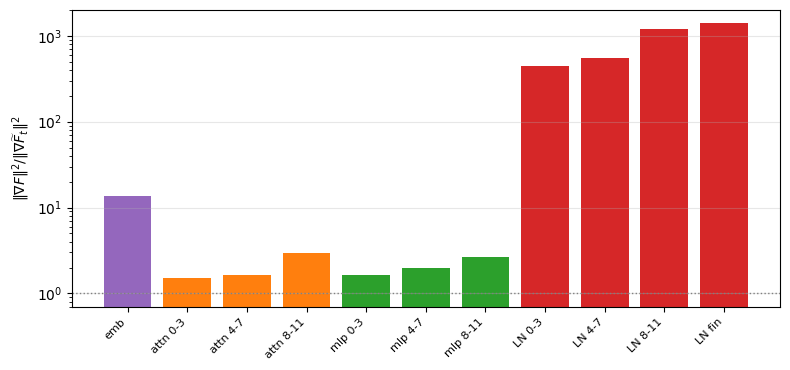

In [4]:
la = json.load(open(f"{GPT}/final_layer_analysis.json"))["w"]
order = ["emb", "low_attn", "mid_attn", "high_attn", "low_mlp", "mid_mlp", "high_mlp",
         "low_ln", "mid_ln", "high_ln", "final"]
labels = ["emb", "attn 0-3", "attn 4-7", "attn 8-11", "mlp 0-3", "mlp 4-7", "mlp 8-11",
          "LN 0-3", "LN 4-7", "LN 8-11", "LN fin"]
vals = [la[g]["ratio"] for g in order]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(len(order)), vals, color=["tab:purple"] + ["tab:orange"]*3 + ["tab:green"]*3 + ["tab:red"]*4)
ax.set_yscale("log"); ax.axhline(1, color="gray", ls=":", lw=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(r"$\|\nabla F\|^2/\|\nabla\widetilde F_t\|^2$")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## Рестарты с чекпойнта: эффект — свойство метода, а не траектории

ветка 101: val 3.5159 -> 3.5066, отношение критериев 3.33
ветка 102: val 3.5160 -> 3.5073, отношение критериев 3.33
ветка 103: val 3.5161 -> 3.5058, отношение критериев 3.36


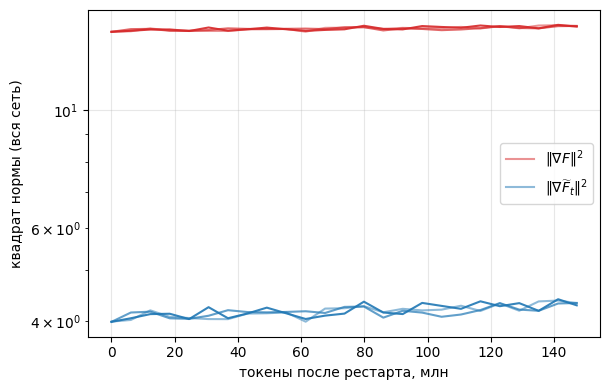

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4))
for i, sd in enumerate((101, 102, 103)):
    d = json.load(open(f"{GPT}/branch_w_seed{sd}.json"))
    steps = sorted(d["diag"], key=int)
    x = np.array([int(s) for s in steps]) * 0.24576
    ax.semilogy(x, [d["diag"][s]["global"]["gF2"] for s in steps], color="tab:red",
                alpha=0.5 + 0.2*i, label=r"$\|\nabla F\|^2$" if i == 0 else None)
    ax.semilogy(x, [d["diag"][s]["global"]["gFt2"] for s in steps], color="tab:blue",
                alpha=0.5 + 0.2*i, label=r"$\|\nabla \widetilde F_t\|^2$" if i == 0 else None)
    last = steps[-1]; g = d["diag"][last]["global"]
    print(f"ветка {sd}: val {d['val_loss'][0]:.4f} -> {d['val_loss'][-1]:.4f}, отношение критериев {g['gF2']/g['gFt2']:.2f}")
ax.set_xlabel("токены после рестарта, млн"); ax.set_ylabel("квадрат нормы (вся сеть)")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

## Спасение AdamWH: правило $\eta\lambda/\epsilon$ работает в обе стороны

Поднятие $\epsilon \ge \eta\lambda$ устраняет расходимость, но сплющивает предобуславливатель —
метод деградирует. Рабочей точки на претрейне LLM нет.

In [6]:
for f in sorted(glob.glob(f"{GPT}/rescue_*.json")):
    d = json.load(open(f))
    print(os.path.basename(f), "-> final val:", round(d["final_val"], 3))

rescue_eps1e-3_wh_lr0.0003_wd0.01_s0.json -> final val: 7.853
rescue_eps1e-4_wh_lr0.0003_wd0.01_s0.json -> final val: 7.221


## GLUE (RoBERTa-base): итоговая таблица

In [7]:
ft = json.load(open(f"{GLUE}/final_table.json"))
tbl = {}
for task, row in ft.items():
    for mode, (m, s) in row.items():
        tbl.setdefault({"l2": "AdamL2", "w": "AdamW", "wh": "AdamWH"}[mode], {})[task] = f"{100*m:.1f} ± {100*s:.1f}"
# SST-2 из отдельных прогонов
for mode, name in (("l2", "AdamL2"), ("w", "AdamW"), ("wh", "AdamWH")):
    cand = {}
    for f in glob.glob(f"{GLUE}/sst2_{mode}_*_s0.json"):
        d = json.load(open(f)); cand[d["lr"]] = d["best_metric"] or -1
    lr = max(cand, key=cand.get)
    vals = []
    for s in (0, 1, 2):
        p = f"{GLUE}/sst2_{mode}_lr{lr:g}_wd0.01_s{s}.json"
        if os.path.exists(p):
            vals.append(json.load(open(p))["best_metric"])
    v = np.array(vals) * 100
    tbl[name]["sst2"] = f"{v.mean():.1f} ± {v.std(ddof=1):.1f}"
pd.DataFrame(tbl).T[["rte", "mrpc", "cola", "stsb", "sst2"]]

,rte,mrpc,cola,stsb,sst2
AdamL2,68.7 ± 2.8,92.0 ± 0.5,59.5 ± 1.2,90.2 ± 0.3,93.1 ± 0.4
AdamW,72.2 ± 10.9,92.5 ± 0.6,64.3 ± 1.6,90.7 ± 0.2,94.5 ± 0.1
AdamWH,53.4 ± 1.3,89.3 ± 0.8,46.5 ± 2.4,77.1 ± 0.6,49.1 ± 0.0
